In [1]:
import networkx as nx
import warnings
import pandas as pd
import numpy as np
from cdlib import algorithms, evaluation, viz
from collections import Counter
import matplotlib.pyplot as plt

Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'bayanpy', 'graph_tool', 'infomap'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}


In [2]:
nodes = pd.read_csv('twitch_nodes_10k_final.csv')

In [3]:
edges = pd.read_csv('twitch_edgelist_10k.csv')

In [4]:
G = nx.DiGraph()
for _, row in nodes.iterrows():
    G.add_node(row['ID'], 
               label=row['Label'], 
               type=row['Broadcaster_Type'], 
               followers=row['Total_Followers'])
for _, row in edges.iterrows():
    G.add_edge(row['Source'], row['Target'], weight=row['Weight'])

In [5]:
homyatol_id = None
for node, attrs in G.nodes(data=True):
    if str(attrs.get('label')).lower() == 'homyatol':
        homyatol_id = node
        break
if homyatol_id is not None:
    G.remove_node(homyatol_id)

In [6]:
#map G to G_name
G_name = nx.relabel_nodes(G, {node: G.nodes[node]['label'] for node in G.nodes()})

In [7]:
print('Nodi:', G.number_of_nodes(), ' Archi:', G.number_of_edges())
print('Componenti debolmente connesse:', nx.number_weakly_connected_components(G))
print('Componenti fortemente connesse:', nx.number_strongly_connected_components(G))

wccs = sorted(nx.weakly_connected_components(G), key=len, reverse=True)
print('Dimensione componente debolmente connessa principale:', len(wccs[0]))

if len(wccs) > 1:
    G = G.subgraph(wccs[0]).copy()
    print('Ridotto alla componente principale:', G.number_of_nodes(), 'nodi')

Nodi: 10355  Archi: 17433
Componenti debolmente connesse: 1
Componenti fortemente connesse: 10207
Dimensione componente debolmente connessa principale: 10355


In [8]:
G_und = G.to_undirected()
print('G_und -> nodi:', G_und.number_of_nodes(), ' archi:', G_und.number_of_edges())
print('Componenti connesse (non diretto):', nx.number_connected_components(G_und))

G_und -> nodi: 10355  archi: 14192
Componenti connesse (non diretto): 1


In [9]:
# 1)Leiden (grafo non diretto)
coms_leiden = algorithms.leiden(G_und)
print(coms_leiden.method_name, '->', len(coms_leiden.communities), 'community trovate')

Leiden -> 8 community trovate


In [10]:
# 2) Infomap
coms_infomap = algorithms.infomap(G)
print(coms_infomap.method_name, '(diretto) ->', len(coms_infomap.communities), 'community trovate')

coms_infomap_und = algorithms.infomap(G_und)
print(coms_infomap_und.method_name, '(non diretto) ->', len(coms_infomap_und.communities), 'community trovate')

Infomap (diretto) -> 10 community trovate
Infomap (non diretto) -> 10 community trovate


In [11]:
# 3) ANGEL (overlapping, su grafo non diretto)
# threshold: soglia di merge tra micro-community locali (0-1, default paper ~0.25/0.6)
# min_community_size: filtra le community troppo piccole
coms_angel = algorithms.angel(G_und, threshold=0.25, min_community_size=3)
print(coms_angel.method_name, '->', len(coms_angel.communities), 'community trovate (overlapping)')

ANGEL -> 5 community trovate (overlapping)


In [12]:
def summarize(name, coms, g):
    sizes = [len(c) for c in coms.communities]
    n_singleton = sum(1 for s in sizes if s == 1)
    return {
        'algoritmo': name,
        'n_community': len(sizes),
        'size_media': np.mean(sizes),
        'size_mediana': np.median(sizes),
        'size_max': np.max(sizes),
        'n_singleton': n_singleton,
        'node_coverage': coms.node_coverage,
    }

results_summary = pd.DataFrame([
    summarize('Leiden', coms_leiden, G_und),
    summarize('Infomap', coms_infomap, G),
    summarize('ANGEL', coms_angel, G_und),
])
results_summary

,algoritmo,n_community,size_media,size_mediana,size_max,n_singleton,node_coverage
0,Leiden,8,1294.375,257.0,6547,0,1.000000
1,Infomap,10,1035.500,133.0,6547,0,1.000000
2,ANGEL,5,54.200,50.0,96,0,0.025881


In [13]:
mod_leiden = evaluation.newman_girvan_modularity(G_und, coms_leiden)
mod_infomap = evaluation.newman_girvan_modularity(G, coms_infomap)
mod_infomap_und = evaluation.newman_girvan_modularity(G_und, coms_infomap_und)
mod_angel = evaluation.newman_girvan_modularity(G_und, coms_angel)
print('Modularity Leiden:', mod_leiden.score)
print('Modularity Infomap', mod_infomap.score)
print('Modularity Infomap (non diretto):', mod_infomap_und.score)
print('Modularity ANGEL:', mod_angel.score)

Modularity Leiden: 0.698622807429023
Modularity Infomap 0.261197165186244
Modularity Infomap (non diretto): 0.6937414484111603
Modularity ANGEL: 0.1293396173046822


In [14]:
# per ANGEL (overlapping) usiamo fitness function compatibili con l'overlap
aid_angel = evaluation.average_internal_degree(G_und, coms_angel)
ied_angel = evaluation.internal_edge_density(G_und, coms_angel)
print('ANGEL - average internal degree:', aid_angel.score)
print('ANGEL - internal edge density:', ied_angel.score)

ANGEL - average internal degree: 27.981325301204823
ANGEL - internal edge density: 0.7202408091931268


In [15]:
aid_leiden = evaluation.average_internal_degree(G_und, coms_leiden)
ied_leiden = evaluation.internal_edge_density(G_und, coms_leiden)
aid_infomap = evaluation.average_internal_degree(G_und, coms_infomap)
ied_infomap = evaluation.internal_edge_density(G_und, coms_infomap)
aid_infomap_und = evaluation.average_internal_degree(G_und, coms_infomap_und)
ied_infomap_und = evaluation.internal_edge_density(G_und, coms_infomap_und)
print('Leiden - average internal degree:', aid_leiden.score)
print('Leiden - internal edge density:', ied_leiden.score)
print('Infomap - average internal degree:', aid_infomap.score)
print('Infomap - internal edge density:', ied_infomap.score)
print('Infomap (non diretto) - average internal degree:', aid_infomap_und.score)
print('Infomap (non diretto) - internal edge density:', ied_infomap_und.score)

Leiden - average internal degree: 13.547552894657278
Leiden - internal edge density: 0.33013979497682133
Infomap - average internal degree: 13.881156293201007
Infomap - internal edge density: 0.31405738201266775
Infomap (non diretto) - average internal degree: 13.881156293201007
Infomap (non diretto) - internal edge density: 0.31405738201266775


In [16]:
node_to_type = nx.get_node_attributes(G, 'type')
node_to_followers = nx.get_node_attributes(G, 'followers')

def community_purity(coms, node_to_attr):
    purities = []
    for c in coms.communities:
        vals = [node_to_attr[n] for n in c if n in node_to_attr]
        if not vals:
            continue
        cnt = Counter(vals)
        purities.append(max(cnt.values()) / sum(cnt.values()))
    return purities

purity_table = []
for name, coms in [('Leiden', coms_leiden), ('Infomap', coms_infomap),
                    ('ANGEL', coms_angel)]:
    p = community_purity(coms, node_to_type)
    purity_table.append({'algoritmo': name, 'purity_media': np.mean(p), 'purity_std': np.std(p)})

pd.DataFrame(purity_table)

,algoritmo,purity_media,purity_std
0,Leiden,0.642615,0.158960
1,Infomap,0.665730,0.130364
2,ANGEL,0.758057,0.125586


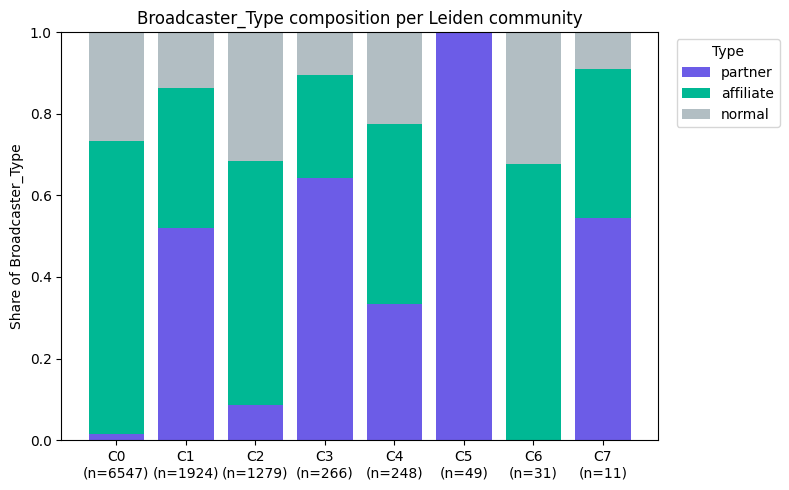

In [ ]:

types_order = ['partner', 'affiliate', 'normal']
colors = {'partner': '#6C5CE7', 'affiliate': '#00B894', 'normal': '#B2BEC3'}

communities_sorted = sorted(coms_leiden.communities, key=len, reverse=True)
labels = [f"C{i}\n(n={len(c)})" for i, c in enumerate(communities_sorted)]

comp_data = []
for c in communities_sorted:
    cnt = Counter(node_to_type[n] for n in c if n in node_to_type)
    total = sum(cnt.values())
    comp_data.append([cnt.get(t, 0) / total for t in types_order])

fig, ax = plt.subplots(figsize=(8, 5))
bottom = [0] * len(comp_data)
for i, t in enumerate(types_order):
    values = [row[i] for row in comp_data]
    ax.bar(labels, values, bottom=bottom, label=t, color=colors[t])
    bottom = [b + v for b, v in zip(bottom, values)]

ax.set_ylabel('Share of Broadcaster_Type')
ax.set_title('Broadcaster_Type composition per Leiden community')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [20]:
# ordina le community di Leiden dalla più grande alla più piccola
# C0 = la più grande, C1 = la seconda più grande, ecc. -- è questa
# la convenzione "C5" usata nel testo e nel grafico
communities_sorted = sorted(coms_leiden.communities, key=len, reverse=True)

rows = []
for i, c in enumerate(communities_sorted):
    followers = [node_to_followers[n] for n in c if n in node_to_followers]
    rows.append({
        'community': f'C{i}',
        'size': len(c),
        'mean_followers': np.mean(followers),
        'median_followers': np.median(followers),
    })

df = pd.DataFrame(rows)
df

,community,size,mean_followers,median_followers
0,C0,6547,1252.140217,286.0
1,C1,1924,52936.516112,7207.5
2,C2,1279,3620.212666,334.0
3,C3,266,65813.086466,20040.5
4,C4,248,47809.604839,1996.0
5,C5,49,241736.632653,111335.0
6,C6,31,3469.548387,2092.0
7,C7,11,29678.090909,12783.0


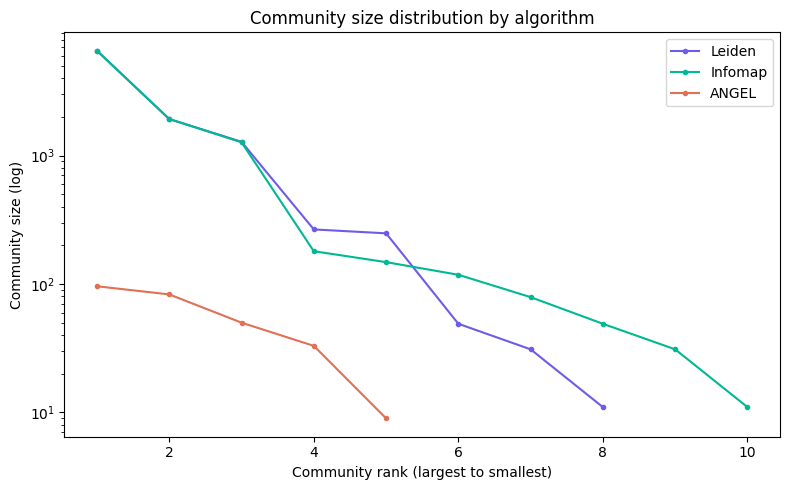

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
for name, coms, color in [('Leiden', coms_leiden, '#6C5CE7'),
                           ('Infomap', coms_infomap, '#00B894'),
                           ('ANGEL', coms_angel, '#E17055')]:
    sizes = sorted([len(c) for c in coms.communities], reverse=True)
    ax.plot(range(1, len(sizes)+1), sizes, marker='o', markersize=3, label=name, color=color)

ax.set_yscale('log')
ax.set_xlabel('Community rank (largest to smallest)')
ax.set_ylabel('Community size (log)')
ax.set_title('Community size distribution by algorithm')
ax.legend()
plt.tight_layout()
plt.show()